The CAR Sales

In [16]:
print('Welcome to the Car sales data')

Welcome to the Car sales data


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [18]:
car_sales_data = pd.read_csv('data/car_sales_data.csv')
car_sales_data.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


In [19]:
car_sales_data.isnull().count()

Manufacturer           50000
Model                  50000
Engine size            50000
Fuel type              50000
Year of manufacture    50000
Mileage                50000
Price                  50000
dtype: int64

In [20]:
car_sales_data.isna().sum()

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

In [21]:
car_sales_data.size

350000

In [22]:
car_sales_data.shape

(50000, 7)

In [23]:
len(car_sales_data)

50000

array([[<AxesSubplot:title={'center':'Engine size'}>,
        <AxesSubplot:title={'center':'Year of manufacture'}>],
       [<AxesSubplot:title={'center':'Mileage'}>,
        <AxesSubplot:title={'center':'Price'}>]], dtype=object)

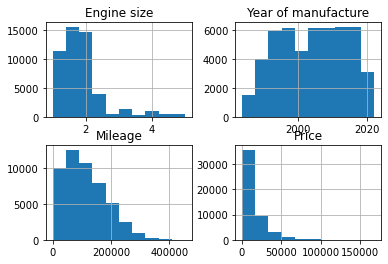

In [24]:
# Convert the data to numerical
car_sales_data.hist()

In [25]:
car_sales_data.dtypes


Manufacturer            object
Model                   object
Engine size            float64
Fuel type               object
Year of manufacture      int64
Mileage                  int64
Price                    int64
dtype: object

In [26]:
car_sales_data.set_index('Manufacturer')

,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
Manufacturer,,,,,,
Ford,Fiesta,1.0,Petrol,2002,127300,3074
Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
Ford,Mondeo,1.6,Diesel,2014,39190,24072
Toyota,RAV4,1.8,Hybrid,1988,210814,1705
VW,Polo,1.0,Petrol,2006,127869,4101
...,...,...,...,...,...,...
BMW,M5,5.0,Petrol,2018,28664,113006
Toyota,Prius,1.8,Hybrid,2003,105120,9430
Ford,Mondeo,1.6,Diesel,2022,4030,49852


In [27]:
car_sales_data['Manufacturer']

0           Ford
1        Porsche
2           Ford
3         Toyota
4             VW
          ...   
49995        BMW
49996     Toyota
49997       Ford
49998       Ford
49999         VW
Name: Manufacturer, Length: 50000, dtype: object

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
# Split the data
X = car_sales_data.drop('Price', axis=1)
y = car_sales_data['Price'] # To be predicted


# split into test and train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [39]:
# Build the model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()

model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9759512171220821

In [31]:
car_sales_data.head(4)

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705


In [32]:
# Turn the categories into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['Manufacturer', 'Model', 'Fuel type', 'Year of manufacture']

one_hot = OneHotEncoder()
transformer = ColumnTransformer([
    ("one_hot", one_hot, categorical_features)
], remainder="passthrough")


transformed_X = transformer.fit_transform(X)
transformed_X

<50000x64 sparse matrix of type '<class 'numpy.float64'>'
	with 300000 stored elements in Compressed Sparse Row format>

In [33]:
transformed_X[:5].toarray()

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 1.00000e+00, 1.27300e+05],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 0.0

In [34]:
transformed_X.toarray()

array([[0.0000e+00, 1.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        1.2730e+05],
       [0.0000e+00, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 4.0000e+00,
        5.7850e+04],
       [0.0000e+00, 1.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.6000e+00,
        3.9190e+04],
       ...,
       [0.0000e+00, 1.0000e+00, 0.0000e+00, ..., 1.0000e+00, 1.6000e+00,
        4.0300e+03],
       [0.0000e+00, 1.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        2.6468e+04],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.4000e+00,
        1.0930e+05]])

In [35]:
car_sales_data

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101
...,...,...,...,...,...,...,...
49995,BMW,M5,5.0,Petrol,2018,28664,113006
49996,Toyota,Prius,1.8,Hybrid,2003,105120,9430
49997,Ford,Mondeo,1.6,Diesel,2022,4030,49852
49998,Ford,Focus,1.0,Diesel,2016,26468,23630


In [36]:
dummies = pd.get_dummies(car_sales_data[['Manufacturer', 'Model', 'Engine size', 'Fuel type', 'Year of manufacture']])
dummies

,Engine size,Year of manufacture,Manufacturer_BMW,Manufacturer_Ford,Manufacturer_Porsche,Manufacturer_Toyota,Manufacturer_VW,Model_718 Cayman,Model_911,Model_Cayenne,...,Model_Passat,Model_Polo,Model_Prius,Model_RAV4,Model_X3,Model_Yaris,Model_Z4,Fuel type_Diesel,Fuel type_Hybrid,Fuel type_Petrol
0,1.0,2002,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,4.0,2016,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1.6,2014,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1.8,1988,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
4,1.0,2006,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,5.0,2018,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
49996,1.8,2003,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
49997,1.6,2022,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
49998,1.0,2016,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [37]:
# Retraining the model
np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2)

model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9828961389897999

In [38]:
np.random.seed(2)

X_train, X_test, y_train, y_test = train_test_split(dummies, y, test_size=0.2)

model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9760307918610587

In [40]:
car_data = pd.read_csv('data/car_sales_data.csv')
car_data.isnull().sum()

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64